SPI Values:
[-0.75217068  0.11352304 -0.24935079 -0.44086337 -0.64002037  0.89930822
  1.95162249  1.28776213  0.14530407 -1.53272152 -1.10541163 -0.94512864
 -0.56666471  0.03323021 -0.40549696 -0.58490088 -0.49438766  1.15664392
  2.02131336  1.32655193  0.06549329 -1.31397183]


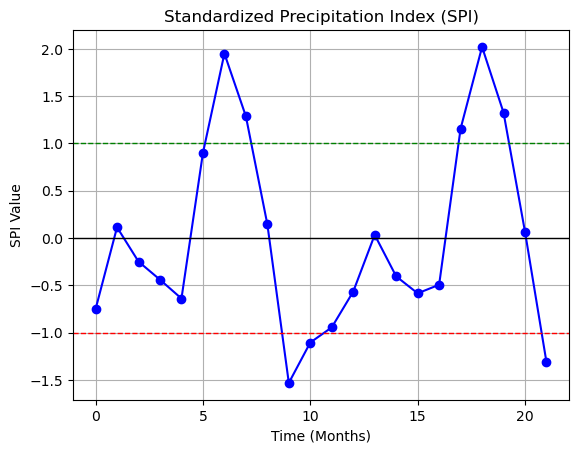

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import gamma, norm
import matplotlib.pyplot as plt

def calculate_spi(precipitation, scale=3):
    """
    Calculate Standardized Precipitation Index (SPI) from a time series of precipitation.

    Parameters:
        precipitation (array-like): A time series of monthly precipitation values.
        scale (int): The timescale over which SPI is computed (e.g., 3 for 3-month SPI).

    Returns:
        spi (array-like): Array of SPI values.
    """
    # Rolling sum to compute SPI for the desired scale
    precip_roll = pd.Series(precipitation).rolling(window=scale).sum().dropna()

    # Fit gamma distribution to precipitation data
    shape, loc, scale_param = gamma.fit(precip_roll, floc=0)

    # Calculate the cumulative probability of the fitted gamma distribution
    cdf = gamma.cdf(precip_roll, shape, loc=loc, scale=scale_param)

    # Convert cumulative probability to standard normal distribution (Z-score)
    spi = norm.ppf(cdf)

    return spi

# Example usage
if __name__ == "__main__":
    # Example precipitation data (in mm) - replace with your time series data
    precipitation = [50, 45, 78, 100, 23, 67, 89, 120, 150, 35, 40, 60,
                     55, 48, 80, 90, 22, 70, 95, 130, 140, 38, 42, 65]

    # Calculate SPI
    spi_values = calculate_spi(precipitation, scale=3)

    # Print SPI values
    print("SPI Values:")
    print(spi_values)

    # Plot SPI values
    plt.plot(spi_values, marker='o', linestyle='-', color='b')
    plt.xlabel('Time (Months)')
    plt.ylabel('SPI Value')
    plt.title('Standardized Precipitation Index (SPI)')
    plt.axhline(0, color='black', lw=1)
    plt.axhline(-1, color='red', lw=1, linestyle='--')
    plt.axhline(1, color='green', lw=1, linestyle='--')
    plt.grid()
    plt.show()


SPI Values:
[-0.75217068  0.11352304 -0.24935079 -0.44086337 -0.64002037  0.89930822
  1.95162249  1.28776213  0.14530407 -1.53272152 -1.10541163 -0.94512864
 -0.56666471  0.03323021 -0.40549696 -0.58490088 -0.49438766  1.15664392
  2.02131336  1.32655193  0.06549329 -1.31397183]
SPEI Values:
[-0.75215421  0.11353274 -0.24933801 -0.440854   -0.64001138  0.89931221
  1.9516057   1.28776531  0.14532181 -1.53274742 -1.1054274  -0.94513942
 -0.56666068  0.03323386 -0.40549013 -0.58489356 -0.4943805   1.15663961
  2.02129166  1.3265526   0.06550157 -1.31400139]
PDSI Values:
[0.09345563 0.13691126 0.51036688 1.10382251 0.92727814 1.19073377
 1.6741894  2.46764502 3.56110065 3.50455628 3.49801191 3.69146754
 3.83492316 3.90837879 4.30183442 4.79529005 4.60874568 4.9022013
 5.44565693 6.33911256 7.33256819 7.30602382 7.31947944 7.56293507]


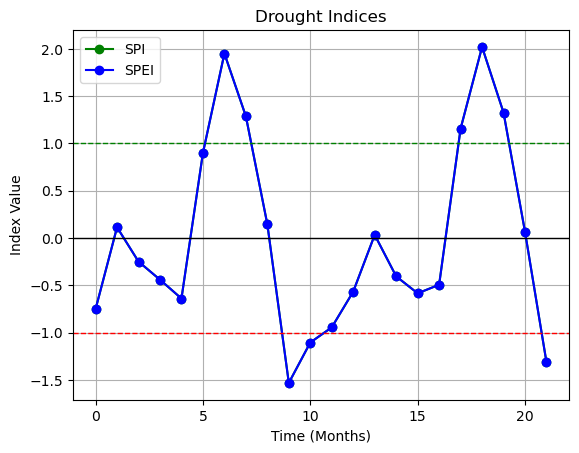

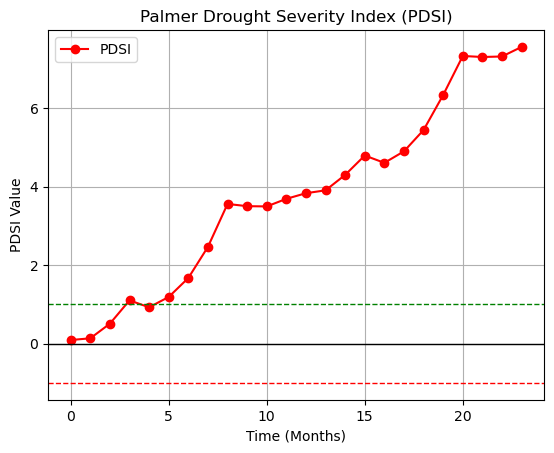

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import gamma, norm
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def calculate_evapotranspiration(temperature, latitude, method='hargreaves'):
    """
    Calculate evapotranspiration using the Hargreaves method.

    Parameters:
        temperature (array-like): A time series of average monthly temperature values (in degrees Celsius).
        latitude (float): Latitude of the location (in decimal degrees).
        method (str): Method to calculate evapotranspiration ('hargreaves' by default).

    Returns:
        evapotranspiration (array-like): Array of evapotranspiration values.
    """
    if method == 'hargreaves':
        # Hargreaves equation: ETo = 0.0023 * (T_mean + 17.8) * (T_max - T_min)^0.5 * Ra
        # Assuming T_mean as input temperature and estimating Ra (extraterrestrial radiation)
        Ra = 0.16 * (np.pi / 180) * latitude  # Simplified Ra calculation
        evapotranspiration = 0.0023 * (np.array(temperature) + 17.8) * Ra
    else:
        raise ValueError("Currently only the 'hargreaves' method is supported.")

    return evapotranspiration

def calculate_spi(precipitation, scale=3):
    """
    Calculate Standardized Precipitation Index (SPI) from a time series of precipitation.

    Parameters:
        precipitation (array-like): A time series of monthly precipitation values.
        scale (int): The timescale over which SPI is computed (e.g., 3 for 3-month SPI).

    Returns:
        spi (array-like): Array of SPI values.
    """
    # Rolling sum to compute SPI for the desired scale
    precip_roll = pd.Series(precipitation).rolling(window=scale).sum().dropna()

    # Fit gamma distribution to precipitation data
    shape, loc, scale_param = gamma.fit(precip_roll, floc=0)

    # Calculate the cumulative probability of the fitted gamma distribution
    cdf = gamma.cdf(precip_roll, shape, loc=loc, scale=scale_param)

    # Convert cumulative probability to standard normal distribution (Z-score)
    spi = norm.ppf(cdf)

    return spi

def calculate_spei(precipitation, evapotranspiration, scale=3):
    """
    Calculate Standardized Precipitation Evapotranspiration Index (SPEI) from time series of precipitation and evapotranspiration.

    Parameters:
        precipitation (array-like): A time series of monthly precipitation values.
        evapotranspiration (array-like): A time series of monthly evapotranspiration values.
        scale (int): The timescale over which SPEI is computed (e.g., 3 for 3-month SPEI).

    Returns:
        spei (array-like): Array of SPEI values.
    """
    # Calculate climatic water balance (precipitation - evapotranspiration)
    water_balance = np.array(precipitation) - np.array(evapotranspiration)

    # Rolling sum to compute SPEI for the desired scale
    water_balance_roll = pd.Series(water_balance).rolling(window=scale).sum().dropna()

    # Fit gamma distribution to water balance data
    shape, loc, scale_param = gamma.fit(water_balance_roll, floc=0)

    # Calculate the cumulative probability of the fitted gamma distribution
    cdf = gamma.cdf(water_balance_roll, shape, loc=loc, scale=scale_param)

    # Convert cumulative probability to standard normal distribution (Z-score)
    spei = norm.ppf(cdf)

    return spei

def calculate_pdsi(precipitation, temperature, awc=100):
    """
    Calculate Palmer Drought Severity Index (PDSI).

    Parameters:
        precipitation (array-like): A time series of monthly precipitation values.
        temperature (array-like): A time series of average monthly temperature values (in degrees Celsius).
        awc (float): Available water capacity of the soil (in mm).

    Returns:
        pdsi (array-like): Array of PDSI values.
    """
    # Normalize temperature and precipitation
    precipitation = np.array(precipitation)
    temperature = np.array(temperature)

    # Calculate potential evapotranspiration (PET) using Thornthwaite's method
    mean_temp = np.mean(temperature)
    pet = 1.6 * (10 * mean_temp / 30) ** 1.514

    # Water balance calculations
    balance = precipitation - pet
    balance_cumsum = np.cumsum(balance)

    # Calculate PDSI using a simple water balance approach
    pdsi = balance_cumsum / awc

    return pdsi

# Example usage
if __name__ == "__main__":
    # Example precipitation and temperature data (in mm and degrees Celsius) - replace with your time series data
    precipitation = [50, 45, 78, 100, 23, 67, 89, 120, 150, 35, 40, 60,
                     55, 48, 80, 90, 22, 70, 95, 130, 140, 38, 42, 65]
    temperature = [20, 22, 25, 30, 18, 24, 28, 32, 35, 19, 21, 26,
                   23, 22, 27, 29, 17, 25, 30, 33, 34, 20, 23, 27]
    latitude = 35.0  # Example latitude

    # Calculate evapotranspiration
    evapotranspiration = calculate_evapotranspiration(temperature, latitude)

    # Calculate SPI
    spi_values = calculate_spi(precipitation, scale=3)

    # Calculate SPEI
    spei_values = calculate_spei(precipitation, evapotranspiration, scale=3)

    # Calculate PDSI
    pdsi_values = calculate_pdsi(precipitation, temperature)

    # Print SPI, SPEI, and PDSI values
    print("SPI Values:")
    print(spi_values)
    print("SPEI Values:")
    print(spei_values)
    print("PDSI Values:")
    print(pdsi_values)

    # Plot SPI, SPEI, and PDSI values
    plt.plot(spi_values, marker='o', linestyle='-', color='g', label='SPI')
    plt.plot(spei_values, marker='o', linestyle='-', color='b', label='SPEI')
    plt.xlabel('Time (Months)')
    plt.ylabel('Index Value')
    plt.title('Drought Indices')
    plt.axhline(0, color='black', lw=1)
    plt.axhline(-1, color='red', lw=1, linestyle='--')
    plt.axhline(1, color='green', lw=1, linestyle='--')
    plt.grid()
    plt.legend()
    plt.show()

    # Plot PDSI values
    plt.plot(pdsi_values, marker='o', linestyle='-', color='r', label='PDSI')
    plt.xlabel('Time (Months)')
    plt.ylabel('PDSI Value')
    plt.title('Palmer Drought Severity Index (PDSI)')
    plt.axhline(0, color='black', lw=1)
    plt.axhline(-1, color='red', lw=1, linestyle='--')
    plt.axhline(1, color='green', lw=1, linestyle='--')
    plt.grid()
    plt.legend()
    plt.show()
